# Sampling and Distributions

## *Workshop 5*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W05.%20Distributions%20and%20Basic%20Statistics.ipynb)

For the next few weeks we'll be working with an extract of the U.S. Census Bureau's [Current Population Survey (CPS)](https://www.census.gov/programs-surveys/cps.html): a large, monthly household survey that is the source of official U.S. statistics on employment, earnings and union membership.

This workshop follows the lecture: we start with **where the data came from** (populations, samples, selection bias), then **summarise** it, then use the **Central Limit Theorem** to see how much a single sample can tell us about a population, and finally put a number on that uncertainty: the **standard error**.

### Aims

- Tell a **population** from a **sample**, and spot **selection bias**
- Choose appropriate summary statistics (mean, median, mode, variance, standard deviation) for different variables
- Plot and interpret distributions
- Build intuition for the **Central Limit Theorem** by simulation, using union membership (as in the lecture)
- Quantify uncertainty with the **standard error**, and see why a bigger sample does *not* fix a biased one

The core path takes roughly two hours. Sections marked **(Optional)** are extensions.

## Setup

We'll use `pandas` for data, `numpy` for maths and random numbers, and `matplotlib`/`seaborn` for plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style="white", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 5)

# A random number generator with a fixed seed, so your numbers match the ones on the website.
# Change the seed (or delete it) to see how the results vary from run to run.
rng = np.random.default_rng(42)

In [2]:
cps = pd.read_csv("https://storage.googleapis.com/qm2/wk7/cps.csv")
cps.head()

,year,state,age,sex,race,sch,ind,union,incwage,realhrwage,occupation
0,1990,36,58,1,3,12.0,871,0.0,14200.0,12.269874,Office and Admin Support
1,2009,5,28,1,1,12.0,8660,1.0,17680.0,8.635149,Office and Admin Support
2,1990,36,37,1,1,14.0,380,1.0,28000.0,21.169851,.
3,1990,6,34,1,1,18.0,740,1.0,27500.0,20.447746,Computer and Math Technicians
4,1981,51,38,1,4,13.0,798,NaN,17000.0,18.892282,Managers


The dataframe has one row per person and these columns:

| column | meaning |
|---|---|
| `year` | survey year |
| `state` | state (FIPS code) |
| `age` | age in years |
| `sex` | 1 = male, 2 = female |
| `race` | 1 = White non-Hispanic, 2 = Black non-Hispanic, 3 = Hispanic, 4 = Other non-Hispanic |
| `sch` | years of schooling (12 = high school, 13 = some college, 14 = associate's, 16 = BA, 18 = advanced degree) |
| `ind` | [industry code](https://www.census.gov/naics/) |
| `union` | 0 = not asked (N/A), 1 = not covered by a union, 2 = member of a labour union, 3 = covered by a union but not a member |
| `incwage` | annual wage and salary income ($) |
| `realhrwage` | real hourly wage ($) |
| `occupation` | occupation group (`.` = missing) |

## 1. Populations, samples and selection bias

In the lecture we met Abraham Wald and the bombers: the Navy's data only contained planes that **made it back**, so the bullet holes showed where a plane *could* be hit and survive. The lesson: before computing anything, ask **how did this row end up in my dataset?**

- A **population** is the set of all relevant measurements (e.g. all U.S. workers).
- A **sample** is a group of observations drawn in some way from that population (e.g. the people the CPS interviewed).
- If the sample is not drawn at random, we risk **selection bias**; **survivorship bias** is a special case.

The CPS is a carefully designed random sample of households. But *this extract* has also been filtered by whoever prepared it. Let's check who is actually in it.

In [3]:
cps[["year", "age", "incwage", "realhrwage"]].agg(["min", "max"])

,year,age,incwage,realhrwage
min,1981,25,15.0,2.00000
max,2013,64,1259999.0,294610.96875


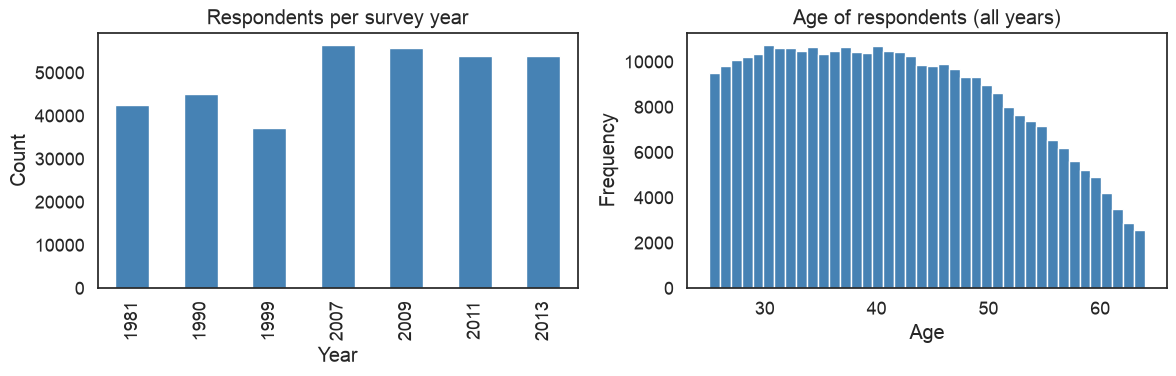

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cps["year"].value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
axes[0].set(title="Respondents per survey year", xlabel="Year", ylabel="Count")
cps["age"].plot.hist(bins=40, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set(title="Age of respondents (all years)", xlabel="Age")
plt.tight_layout()
plt.show()

### Exercise: who is in the sample, and who isn't?

Using the table and plots above, plus the CPS [methodology page](https://www.census.gov/programs-surveys/cps/technical-documentation/methodology.html):

1. Nobody in this file is under 25 or over 64, and everyone has **positive wage income**. So what is the *population* this sample can speak about? Is it "Americans"? "American workers"?
2. Who is systematically missing (think: students, retirees, the unemployed, the self-employed, people without a fixed address)?
3. Suppose a journalist uses this file to report "the average American earns \$X". What's wrong with that sentence?
4. How is the CPS sample drawn in the first place? Where could selection bias still creep in even with a random design (hint: who *answers* a survey)?

*Write your answers in the markdown cell below.*

*Your answers here.*

## 2. Summary statistics

We'll focus on the most recent survey wave, **2013**. `describe()` gives the count, mean, standard deviation, min/max and quartiles (the 50% quartile is the **median**) of every numeric column.

In [5]:
df = cps[cps["year"] == 2013].copy()
df["income"] = df["incwage"] / 1000   # income in $ thousands: easier to read
df.describe().round(2)

,year,state,age,sex,race,sch,ind,union,incwage,realhrwage,income
count,53790.0,53790.00,53790.00,53790.00,53790.00,53790.00,53790.00,53790.00,53790.00,53790.00,53790.00
mean,2013.0,27.89,42.91,1.49,1.69,13.93,6363.97,0.19,51821.86,24.38,51.82
std,0.0,16.09,10.56,0.50,1.02,2.74,2612.37,0.46,60163.45,151.90,60.16
min,2013.0,1.00,25.00,1.00,1.00,0.00,170.00,0.00,38.00,2.01,0.04
25%,2013.0,12.00,34.00,1.00,1.00,12.00,4870.00,0.00,24000.00,12.17,24.00
50%,2013.0,27.00,43.00,1.00,1.00,13.00,7380.00,0.00,40000.00,18.44,40.00
75%,2013.0,42.00,51.00,2.00,3.00,16.00,8190.00,0.00,63000.00,28.12,63.00
max,2013.0,56.00,64.00,2.00,4.00,18.00,9590.00,3.00,1102999.00,34760.80,1103.00


### Exercise

From the table above:

1. What is the median hourly wage (`realhrwage`)? And the mean? Why are they different?
2. What is the average age?
3. Are there more men or women? (Hint: `sex` is 1 or 2, so its mean tells you the share of women... how?)
4. Interpret the mean of the `race` column. Does it mean anything?

*Your answers here.*

### Categorical variables: use the mode

`race`, `sex`, `union` and `occupation` are **categorical**: the numbers are labels, not quantities, so their mean is meaningless. For categorical variables the most representative value is the **mode** (the most common category). Telling pandas a column is categorical stops it from computing nonsense:

In [6]:
for col in ["race", "sex", "union"]:
    df[col] = df[col].astype("category")

df["race"].describe()   # count, number of unique values, top (= mode) and its frequency

count     53790
unique        4
top           1
freq      34662
Name: race, dtype: int64

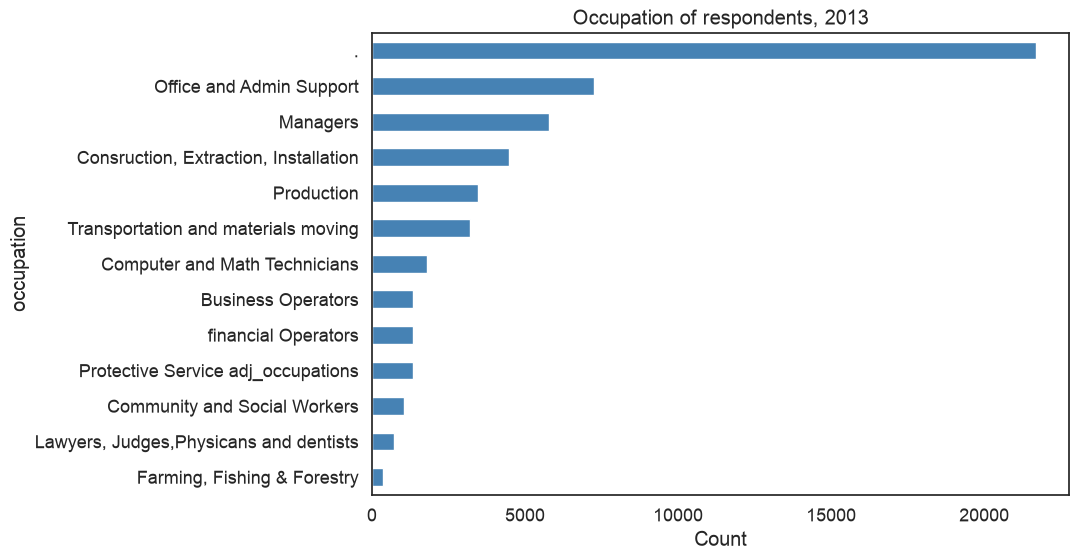

In [7]:
occ = df["occupation"].value_counts()
occ.sort_values().plot.barh(color="steelblue", figsize=(9, 6))
plt.title("Occupation of respondents, 2013")
plt.xlabel("Count")
plt.show()

### Exercise

1. What is the modal (most common) occupation? Be careful: what does the `.` category mean, and should it count?
2. Roughly what share of 2013 respondents have a missing occupation? If people with a missing occupation differ systematically from the rest (e.g. they earn less), what happens to any analysis that silently drops them?

In [8]:
# your code here

### Mean vs median: skewed distributions

Income is the classic **skewed** variable: most people earn a moderate amount, a few earn a lot. Let's plot its distribution with a **histogram** and mark the mean and median.

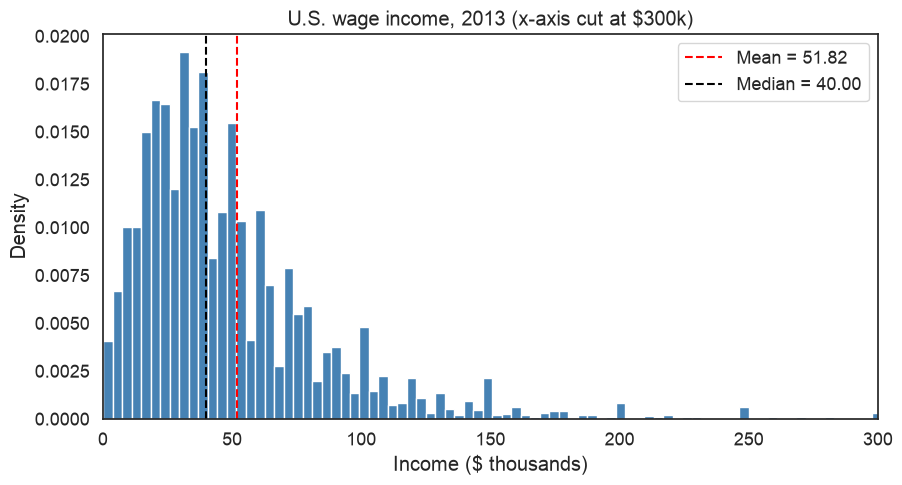

In [9]:
def plot_histogram(variable, bins=50, xlab="", title="", xlim=None):
    # Histogram of a pandas Series with its mean and median marked
    plt.hist(variable, bins=bins, edgecolor="white", density=True, color="steelblue")
    plt.axvline(variable.mean(), color="red", linestyle="--", label=f"Mean = {variable.mean():.2f}")
    plt.axvline(variable.median(), color="black", linestyle="--", label=f"Median = {variable.median():.2f}")
    if xlim is not None:
        plt.xlim(xlim)
    plt.xlabel(xlab)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()

plot_histogram(df["income"], bins=300, xlab="Income ($ thousands)",
               title="U.S. wage income, 2013 (x-axis cut at $300k)", xlim=(0, 300))

### Exercise

1. Why is the mean larger than the median? Interpret this in terms of income inequality.
2. There are spikes at round numbers (\$50k, \$100k, \$150k ...). Is that because employers love round salaries, or because of *how the data were collected*? What does this tell you about self-reported survey data?
3. **Outliers.** Run the cell below, which adds a single person earning \$1 billion to the data. How much do the mean and the median move?

In [10]:
with_billionaire = pd.concat([df["income"], pd.Series([1_000_000])])   # $1bn = 1,000,000 thousand
print("Mean   before/after:", round(df["income"].mean(), 2), "/", round(with_billionaire.mean(), 2))
print("Median before/after:", round(df["income"].median(), 2), "/", round(with_billionaire.median(), 2))

Mean   before/after: 51.82 / 70.41
Median before/after: 40.0 / 40.0


### Spot the problem: the \$34,000-an-hour worker

A colleague sends you this summary and writes: *"The average American worker earns \$24.38 an hour."*

In [11]:
df["realhrwage"].describe().round(2)

count    53790.00
mean        24.38
std        151.90
min          2.01
25%         12.17
50%         18.44
75%         28.12
max      34760.80
Name: realhrwage, dtype: float64

### Exercise

1. Look at the maximum. Is that plausible for a survey of wage earners? Find that person's row (hint: `df.sort_values("realhrwage").tail()`), and compare their hourly wage with their annual `income`.
2. Recompute the mean hourly wage *without* the top row. How much did one row move the mean? And the median?
3. Rewrite your colleague's sentence so that it is honest about (a) the population and (b) the choice of summary statistic.

In [12]:
# your code here

### Measures of spread: variance and standard deviation

The mean tells us where the centre is; the **standard deviation** tells us how far a typical observation is from it.

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2 \qquad s=\sqrt{s^2}$$

The lecture compared a high-SD sample A with a low-SD sample B. Here is a real version: incomes in two occupations.

In [13]:
x = df.loc[df["occupation"] == "Office and Admin Support", "income"]

# the formula, by hand
s2 = ((x - x.mean())**2).sum() / (len(x) - 1)
print("By hand:  variance =", round(s2, 2), " sd =", round(np.sqrt(s2), 2))
print("pandas:   variance =", round(x.var(), 2), " sd =", round(x.std(), 2))

By hand:  variance = 1386.43  sd = 37.23
pandas:   variance = 1386.43  sd = 37.23


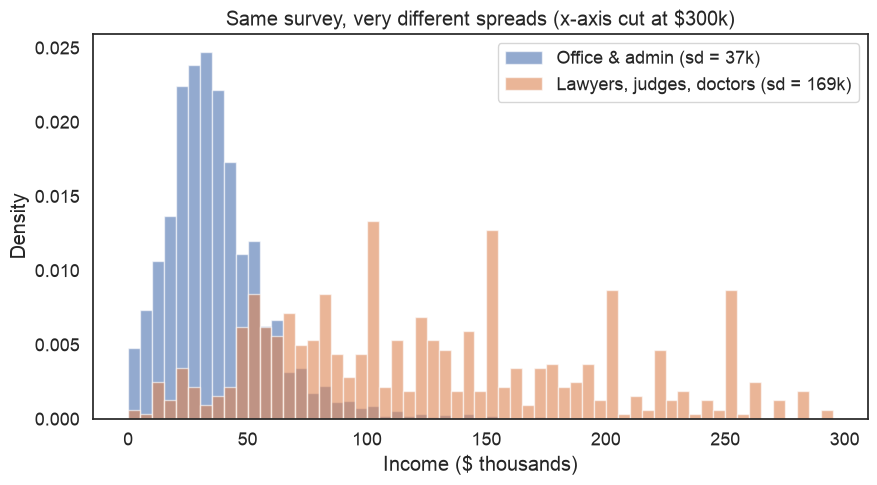

In [14]:
a = df.loc[df["occupation"] == "Lawyers, Judges,Physicans and dentists", "income"]
b = df.loc[df["occupation"] == "Office and Admin Support", "income"]

bins = np.arange(0, 300, 5)
plt.hist(b, bins=bins, density=True, alpha=0.6, label=f"Office & admin (sd = {b.std():.0f}k)")
plt.hist(a, bins=bins, density=True, alpha=0.6, label=f"Lawyers, judges, doctors (sd = {a.std():.0f}k)")
plt.xlabel("Income ($ thousands)"); plt.ylabel("Density")
plt.title("Same survey, very different spreads (x-axis cut at $300k)")
plt.legend(); plt.show()

### Exercise

1. Use `plot_histogram()` to plot the distribution of `age` (try 40 bins). Is it skewed? Does the mean differ much from the median?
2. Plot the distribution of years of schooling (`sch`). Pick a sensible number of bins, label it clearly, and explain the two big spikes.
3. For which of `income`, `age` and `sch` is the mean a good summary of a "typical" person? For which would you report the median?

In [15]:
# your code here

In [16]:
# your code here

Before moving on, we'll drop the small number of people earning over \$200k (about 1.6% of 2013 respondents), as in the lecture. This is a **choice**, and it changes the population we're describing (to "wage earners under \$200k"), so always report it.

In [17]:
print("Share of 2013 respondents earning over $200k:", round((df["income"] >= 200).mean(), 4))
df = df[df["income"] < 200]

Share of 2013 respondents earning over $200k: 0.0161


## 3. The Central Limit Theorem

### Estimating union membership in America

As in the lecture, let's ask: **what share of American workers are members of a labour union?**

The CPS only asks the union question to part of its sample (that's the `union = 0`, "N/A", group). So our **population** for this section is the 2013 respondents who were asked, and we create a binary variable: 1 = union member, 0 = not a member.

For the rest of the workshop we'll **pretend this group is the entire population**, so we know the true answer and can see how well samples recover it.

In [18]:
unions = df[df["union"] != 0].copy()
unions["member"] = (unions["union"] == 2).astype(int)

p = unions["member"].mean()
print(f"Population: {len(unions):,} people. True union membership rate: {p:.3f}")

Population: 8,697 people. True union membership rate: 0.141


### A sample of 7

Now imagine we can only afford to interview **7** random people. The code below draws one sample and computes its mean (= the share of union members in the sample). Run it several times.

In [19]:
sample = unions["member"].sample(7, replace=True)
print(sample.values, " -> sample mean:", round(sample.mean(), 3))

[1 0 0 0 0 0 0]  -> sample mean: 0.143


Quite often, *nobody* in the sample is a union member, so our estimate would be **0%**. How often? If each person has a probability $p$ of being a member, the chance that all 7 are not is $(1-p)^7$. Let's check that against a simulation of 10,000 samples.

(Drawing samples in a Python loop is slow, so we'll use `rng.choice` to draw all 10,000 samples at once as rows of a matrix, then take the mean of each row.)

In [20]:
def sample_means(values, n, reps=10_000):
    # Draw `reps` random samples of size n (with replacement) and return the mean of each
    values = np.asarray(values)
    draws = rng.choice(values, size=(reps, n), replace=True)
    return draws.mean(axis=1)

means7 = sample_means(unions["member"], n=7)
print("Theory:     P(all 7 are non-members) =", round((1 - p)**7, 3))
print("Simulation: share of samples with mean 0 =", round((means7 == 0).mean(), 3))

Theory:     P(all 7 are non-members) = 0.344
Simulation: share of samples with mean 0 = 0.346


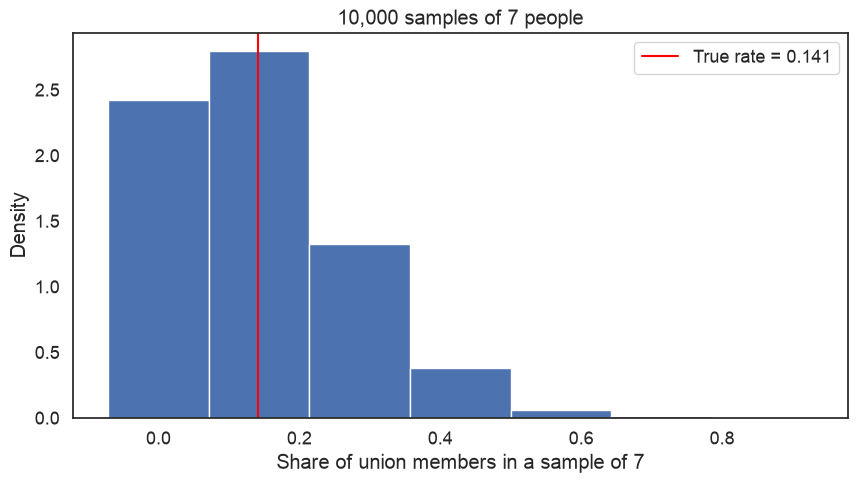

In [21]:
plt.hist(means7, bins=np.arange(-1/14, 1, 1/7), edgecolor="white", density=True)
plt.axvline(p, color="red", label=f"True rate = {p:.3f}")
plt.xlabel("Share of union members in a sample of 7")
plt.ylabel("Density")
plt.title("10,000 samples of 7 people")
plt.legend(); plt.show()

### Exercise

1. With samples of 7, what is the range of estimates you could plausibly get? Would you trust a single one?
2. Using the formula $(1-p)^n$, how likely is a sample of **1,000** people with *zero* union members? Now simulate it.
3. The lecture asked: "but *how* unlikely?" Answering that precisely is what the Central Limit Theorem is for.

In [22]:
# your code here

### The sampling distribution becomes normal

The distribution of sample means is called the **sampling distribution**. Watch what happens to it as the sample size grows. The black curve is a normal distribution with the same mean and standard deviation as the simulated means.

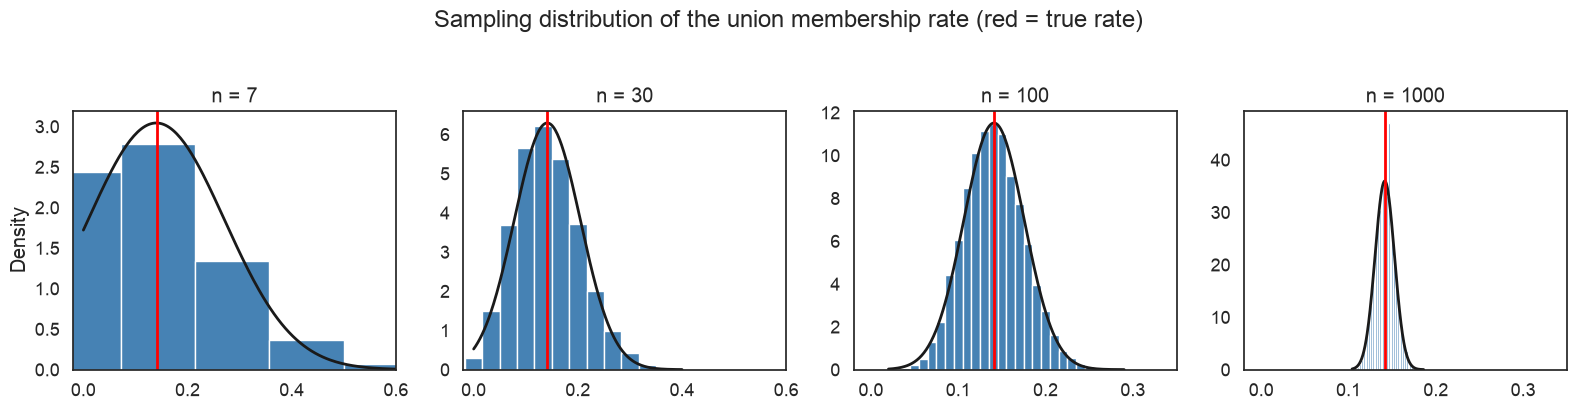

In [23]:
def plot_sampling_distribution(means, ax, true_mean, title, n=None):
    # For a 0/1 variable the sample mean can only take the values 0, 1/n, 2/n, ...
    # so if n is given (and small) we use one bar per possible value.
    bins = (np.arange(n + 2) - 0.5) / n if (n is not None and n <= 200) else 40
    ax.hist(means, bins=bins, density=True, color="steelblue", edgecolor="white")
    mu, sd = means.mean(), means.std()
    xs = np.linspace(means.min(), means.max(), 200)
    ax.plot(xs, norm.pdf(xs, mu, sd), "k", lw=2)
    ax.axvline(true_mean, color="red", lw=2)
    ax.set_title(title)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, n in zip(axes, [7, 30, 100, 1000]):
    plot_sampling_distribution(sample_means(unions["member"], n), ax, p, f"n = {n}", n=n)
    ax.set_xlim(-0.02, 0.6 if n < 100 else 0.35)
axes[0].set_ylabel("Density")
fig.suptitle("Sampling distribution of the union membership rate (red = true rate)", y=1.03)
plt.tight_layout(); plt.show()

The underlying variable is just 0s and 1s, as far from a bell curve as it gets. Yet with big enough samples the **sample means** are approximately normal and centred on the true value. That is the **Central Limit Theorem**:

> If you take sufficiently large random samples, the distribution of sample means is approximately normal, *regardless of the distribution of the underlying population*.

### It works for skewed variables too

Income is heavily right-skewed. Compare the distribution of individual incomes (left) with the distribution of the means of samples of 500 people (right).

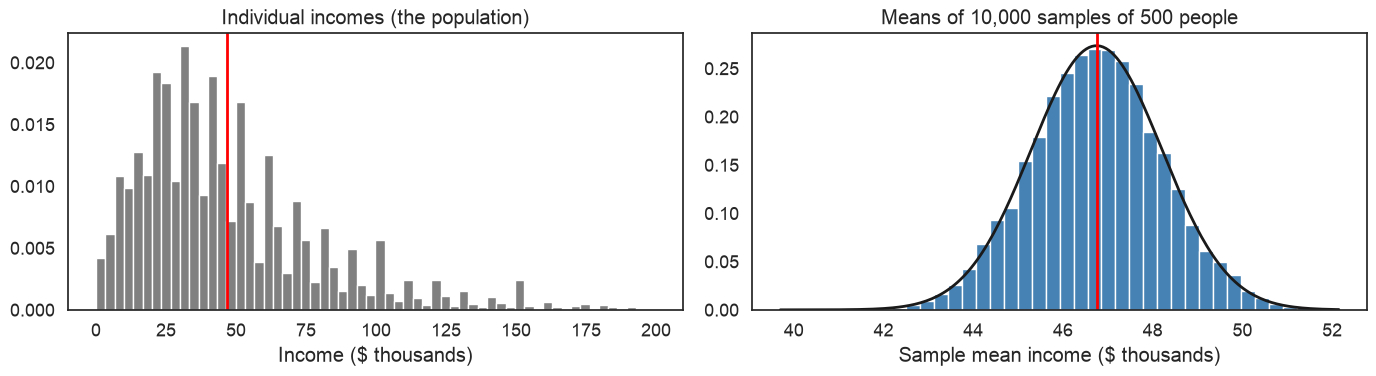

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["income"], bins=60, density=True, color="grey", edgecolor="white")
axes[0].axvline(df["income"].mean(), color="red", lw=2)
axes[0].set(title="Individual incomes (the population)", xlabel="Income ($ thousands)")
plot_sampling_distribution(sample_means(df["income"], 500), axes[1], df["income"].mean(),
                           "Means of 10,000 samples of 500 people")
axes[1].set_xlabel("Sample mean income ($ thousands)")
plt.tight_layout(); plt.show()

### Exercise

1. Repeat the two-panel plot for `age` and for `sch` (years of schooling). How non-normal are the raw distributions? Are the sampling distributions normal?
2. Try a small sample size (e.g. n = 5) for income. At what sample size does the sampling distribution start to look normal? Is it the same for a symmetric variable like age?

In [25]:
# your code here

### (Optional) When the CLT is slow: one bad row

The CLT says "sufficiently large". How large depends on the data. Remember the \$34,000-an-hour worker? Plot the sampling distribution of mean `realhrwage` for n = 1,000 and describe what you see. Why is there a second bump? What does this tell you about checking your data *before* trusting a textbook result?

In [26]:
# your code here: plot the sampling distribution of df["realhrwage"] for n = 1000

## 4. Quantifying uncertainty: the standard error

The standard deviation of the sampling distribution has a name: the **standard error** (SE). It measures how far a sample mean typically lands from the population mean. The CLT also tells us how it depends on sample size:

$$SE = \frac{\sigma}{\sqrt{n}}$$

where $\sigma$ is the population standard deviation. Let's check that against simulation.

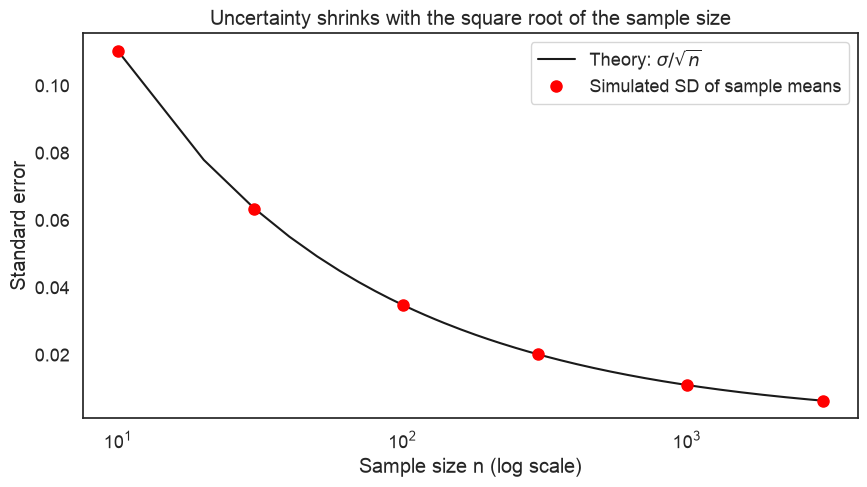

In [27]:
sigma = unions["member"].std()
ns = [10, 30, 100, 300, 1000, 3000]
simulated_se = [sample_means(unions["member"], n, reps=5000).std() for n in ns]

grid = np.linspace(10, 3000, 300)
plt.plot(grid, sigma / np.sqrt(grid), "k-", label=r"Theory: $\sigma/\sqrt{n}$")
plt.plot(ns, simulated_se, "o", color="red", ms=8, label="Simulated SD of sample means")
plt.xscale("log")
plt.xlabel("Sample size n (log scale)"); plt.ylabel("Standard error")
plt.title("Uncertainty shrinks with the square root of the sample size")
plt.legend(); plt.show()

Because the sampling distribution is normal, the 68-95-99.7 rule applies: about **95% of sample means land within 2 standard errors** of the population mean. Let's check.

In [28]:
n = 1000
se = sigma / np.sqrt(n)
means = sample_means(unions["member"], n)
for k in [1, 2, 3]:
    share = (np.abs(means - p) < k * se).mean()
    print(f"Within {k} SE of the true rate: {share:.3f}")

Within 1 SE of the true rate: 0.682
Within 2 SE of the true rate: 0.954
Within 3 SE of the true rate: 0.997


### Why the CLT is magic

So far we've cheated: we know the population, so we could draw thousands of samples. In real life you get **one** sample. The CLT means that is enough: estimate $\sigma$ with the sample standard deviation $s$, compute $SE = s/\sqrt{n}$, and you know roughly how far off you might be. (Next week we turn this into a formal **confidence interval**.)

In [29]:
one_sample = unions["member"].sample(1000, random_state=1)
est = one_sample.mean()
se_hat = one_sample.std() / np.sqrt(len(one_sample))
print(f"Estimate from ONE sample of 1000: {est:.3f}, standard error {se_hat:.3f}")
print(f"Estimate +/- 2 SE: {est - 2*se_hat:.3f} to {est + 2*se_hat:.3f}   (true rate: {p:.3f})")

Estimate from ONE sample of 1000: 0.138, standard error 0.011
Estimate +/- 2 SE: 0.116 to 0.160   (true rate: 0.141)


### Signal and noise: has union membership fallen?

Union membership in the U.S. has been declining for decades. Our data cover 1990 as well as 2013. The **signal** is the difference between the two rates; the **noise** is how much sample means bounce around (the standard error). A signal only means something if it is large relative to the noise.

The plot shows the sampling distributions of the membership rate in each year for samples of size `n`.

True rate 1990: 0.187   2013: 0.141


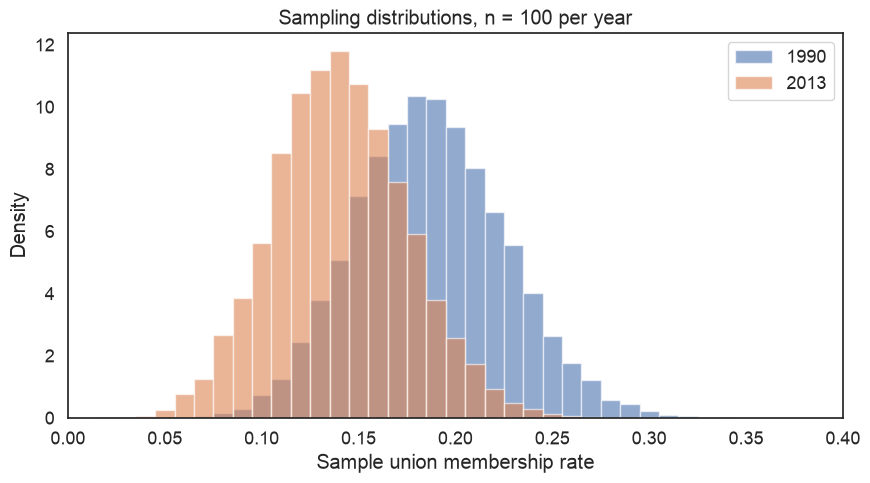

In [30]:
u90 = cps[(cps["year"] == 1990) & (cps["union"] > 0) & (cps["incwage"] < 200_000)]
member90 = (u90["union"] == 2).astype(int)
member13 = unions["member"]
print(f"True rate 1990: {member90.mean():.3f}   2013: {member13.mean():.3f}")

def compare_years(n):
    for values, label in [(member90, "1990"), (member13, "2013")]:
        m = sample_means(values, n)
        bins = (np.arange(n + 2) - 0.5) / n if n <= 200 else 40
        plt.hist(m, bins=bins, density=True, alpha=0.6, label=label)
    plt.xlim(0, 0.4)
    plt.xlabel("Sample union membership rate"); plt.ylabel("Density")
    plt.title(f"Sampling distributions, n = {n} per year")
    plt.legend(); plt.show()

compare_years(100)

### Exercise

1. With samples of 100 per year, could you confidently say membership fell? Why not?
2. Increase `n` (try 500, 1000, 3000). At roughly what sample size do the two distributions stop overlapping (say, their means are more than 3 SEs apart)?
3. In your own words: what is the "signal", what is the "noise", and why does a bigger sample help us see the signal?

In [31]:
# your code here

## 5. Spot the problem: a big sample from the wrong people

A polling company runs an **opt-in online wage survey** and reports:

> *"Based on 10,000 responses, the average U.S. wage earner makes \$X thousand a year, with a standard error of just \$0.4 thousand."*

The catch: who answers? Suppose people with higher incomes (and more education) are more likely to answer online surveys, which is a well-documented pattern in polling. Below we **simulate** this: each person in our "population" answers with a probability that rises with their income. Read the code, run it, and then diagnose the claim.

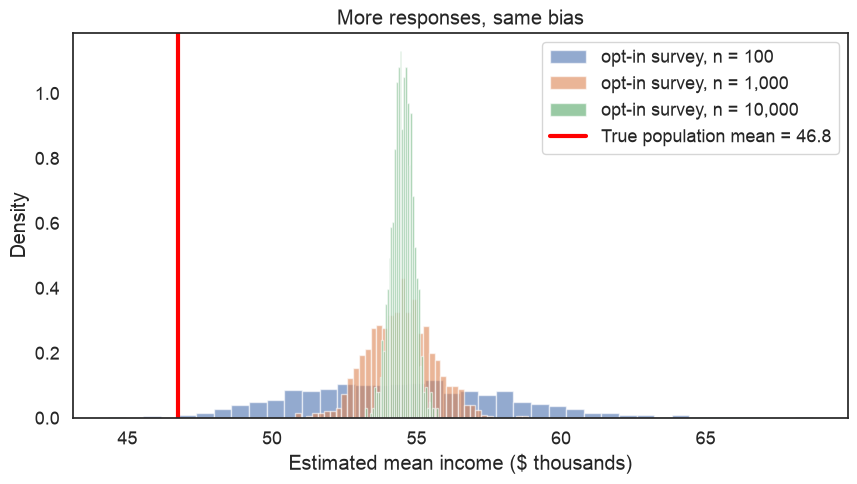

In [32]:
# Probability of responding rises with income: about 7% at $10k, about 14% at $150k
response_prob = 0.05 + 0.10 / (1 + np.exp(-(df["income"] - 60) / 30))

def biased_survey_means(n, reps=1000):
    # Mean income from `reps` opt-in surveys of n respondents each
    weights = response_prob / response_prob.sum()
    draws = rng.choice(df["income"].to_numpy(), size=(reps, n), replace=True, p=weights.to_numpy())
    return draws.mean(axis=1)

true_mean = df["income"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
for n in [100, 1000, 10_000]:
    m = biased_survey_means(n)
    ax.hist(m, bins=40, density=True, alpha=0.6, label=f"opt-in survey, n = {n:,}")
ax.axvline(true_mean, color="red", lw=3, label=f"True population mean = {true_mean:.1f}")
ax.set(xlabel="Estimated mean income ($ thousands)", ylabel="Density",
       title="More responses, same bias")
ax.legend(); plt.show()

### Exercise

1. What happens to the **spread** of the estimates as n grows? What happens to their **centre**?
2. Is the reported standard error of \$0.4k correct? Is it a useful measure of how wrong the estimate is? Why not?
3. Which assumption behind the Central Limit Theorem (and the standard error) is violated here?
4. Connect this to Wald's bombers: what is the "plane that didn't come back" in this survey?
5. **Your turn:** a union newsletter runs an online poll of its readers asking "are you a union member?". Adapt the code to simulate a survey in which union members (in `unions`) are 5 times more likely to respond than non-members, and estimate the union membership rate with n = 10,000. How far off is it?

In [33]:
# your code here

## Recap

1. A **population** is the set of all relevant measurements; a **sample** is the part we observe. Always ask how the sample was selected: this CPS extract only covers 25-64 year-old wage earners.
2. Use the **median** for skewed variables, the **mode** for categorical ones, and check extreme values before trusting a mean.
3. **Central Limit Theorem:** for sufficiently large random samples, sample means are approximately normally distributed, whatever the shape of the underlying data.
4. The **standard error** $\sigma/\sqrt{n}$ tells us how much a sample mean bounces around; about 95% of sample means fall within 2 SEs of the population mean.
5. All of this assumes a **random** sample. A huge biased sample gives a very precise wrong answer.

Next week we turn the standard error into **confidence intervals** and **hypothesis tests**, and meet a Bayesian way to estimate union membership.